# Hospital Readmission Prediction

## Case Study

The objective of this project is to predict whether a patient will be readmitted to the hospital within 30 days using patient and hospital encounter information.

A Logistic Regression model with L2 regularization will be used for binary classification. The model will be evaluated primarily using ROC-AUC, along with a confusion matrix and an analysis of false positives and false negatives.

## Objectives

* Perform data preprocessing and exploratory analysis.
* Prepare patient records for machine learning.
* Train a Logistic Regression model with L2 regularization.
* Predict 30-day hospital readmission risk.
* Evaluate the model using ROC-AUC.
* Analyze false positives and false negatives.
* Discuss the clinical cost of incorrect predictions.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report,
    accuracy_score
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
df = pd.read_csv("hospital_readmission.csv")

In [ ]:
print("Dataset Shape:", df.shape)

Dataset Shape: (32300, 10)


In [ ]:
df.head()

,age,length_of_stay_days,num_diagnoses,num_medications,prev_admissions,glucose_level,bmi,has_diabetes,discharge_type,readmitted_30days
0,22.0,28.0,2.0,13.0,4.0,89.1,48.4,1.0,2.0,0
1,44.0,12.0,7.0,11.0,2.0,254.8,23.9,1.0,0.0,1
2,34.0,15.0,9.0,16.0,6.0,270.2,16.7,0.0,1.0,1
3,39.0,15.0,5.0,16.0,6.0,208.6,18.2,0.0,1.0,1
4,62.0,24.0,1.0,6.0,6.0,233.1,44.0,0.0,0.0,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32300 entries, 0 to 32299
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  31653 non-null  object 
 1   length_of_stay_days  31652 non-null  float64
 2   num_diagnoses        31655 non-null  float64
 3   num_medications      31654 non-null  float64
 4   prev_admissions      31654 non-null  float64
 5   glucose_level        31654 non-null  float64
 6   bmi                  31654 non-null  float64
 7   has_diabetes         31653 non-null  float64
 8   discharge_type       31655 non-null  float64
 9   readmitted_30days    32300 non-null  int64  
dtypes: float64(8), int64(1), object(1)
memory usage: 2.5+ MB


In [ ]:
df.describe()

,length_of_stay_days,num_diagnoses,num_medications,prev_admissions,glucose_level,bmi,has_diabetes,discharge_type,readmitted_30days
count,31652.000000,31655.000000,31654.00000,31654.000000,31654.000000,31654.000000,31653.000000,31655.000000,32300.000000
mean,15.008846,7.529521,10.05418,4.500916,179.799055,32.571947,0.355195,0.998136,0.499659
std,8.394087,4.023350,5.57273,2.865609,69.854520,10.098815,0.478580,0.815959,0.500008
min,1.000000,1.000000,1.00000,0.000000,60.000000,-5.000000,0.000000,0.000000,0.000000
25%,8.000000,4.000000,5.00000,2.000000,119.000000,23.900000,0.000000,0.000000,0.000000
50%,15.000000,8.000000,10.00000,5.000000,179.900000,32.600000,0.000000,1.000000,0.000000
75%,22.000000,11.000000,15.00000,7.000000,240.700000,41.200000,1.000000,2.000000,1.000000
max,29.000000,14.000000,200.00000,9.000000,900.000000,50.000000,1.000000,2.000000,1.000000


In [ ]:
df["readmitted_30days"].value_counts()

,count
readmitted_30days,
0,16161
1,16139


In [ ]:
df["readmitted_30days"].value_counts(normalize=True) * 100

,proportion
readmitted_30days,
0,50.034056
1,49.965944


In [ ]:
df.isnull().sum()

,0
age,647
length_of_stay_days,648
num_diagnoses,645
num_medications,646
prev_admissions,646
glucose_level,646
bmi,646
has_diabetes,647
discharge_type,645
readmitted_30days,0


In [ ]:
df.isnull().sum().sum()

np.int64(5816)

In [ ]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 298


In [ ]:
df = df.drop_duplicates()

In [ ]:
print("Dataset Shape after removing duplicates:", df.shape)

Dataset Shape after removing duplicates: (32002, 10)


In [ ]:
df["age"] = pd.to_numeric(df["age"], errors="coerce")

In [ ]:
df.dtypes

,0
age,float64
length_of_stay_days,float64
num_diagnoses,float64
num_medications,float64
prev_admissions,float64
glucose_level,float64
bmi,float64
has_diabetes,float64
discharge_type,float64
readmitted_30days,int64


In [ ]:
for column in df.columns:
    print("\n", column)
    print(df[column].unique()[:20])


 age
[ 22.  44.  34.  39.  62. 150.  48.  88.  70.  40.  52.  86.  54.  87.
  59.  36.  27.  20.  80.  35.]

 length_of_stay_days
[28. 12. 15. 24. 10. 22.  2. 29. 16. 25. 20. 13. 17. 27. nan  6. 26.  9.
 18.  3.]

 num_diagnoses
[ 2.  7.  9.  5.  1.  4. 12.  8.  6. 14. 13.  3. 10. nan 11.]

 num_medications
[ 13.  11.  16.   6.  18.  19.  15.   7.   8.  14.   2.  nan  10. 200.
  17.   5.   4.  12.   9.   3.]

 prev_admissions
[ 4.  2.  6.  8.  5.  1.  9.  7.  0.  3. nan]

 glucose_level
[ 89.1 254.8 270.2 208.6 233.1 268.9 177.2 128.  252.8 102.5 222.7 190.1
 136.4 265.5 204.6 900.  251.7 115.7 280.1 168.1]

 bmi
[48.4 23.9 16.7 18.2 44.  25.9 17.3 42.8 15.6 -5.  38.6 46.4 39.9 35.9
 34.5 38.3 41.1 26.3 24.4 41. ]

 has_diabetes
[ 1.  0. nan]

 discharge_type
[ 2.  0.  1. nan]

 readmitted_30days
[0 1]


## Exploratory Data Analysis

Exploratory data analysis is performed to understand the distribution of the target variable and the characteristics of the patient records before training the machine learning model.


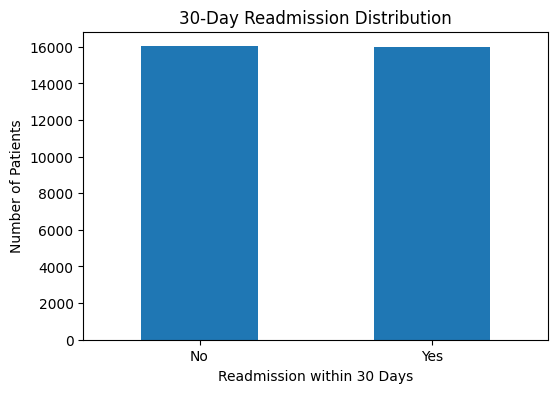

In [ ]:
df["readmitted_30days"].value_counts().plot(
    kind="bar",
    figsize=(6, 4)
)

plt.xlabel("Readmission within 30 Days")
plt.ylabel("Number of Patients")
plt.title("30-Day Readmission Distribution")
plt.xticks([0, 1], ["No", "Yes"], rotation=0)
plt.show()

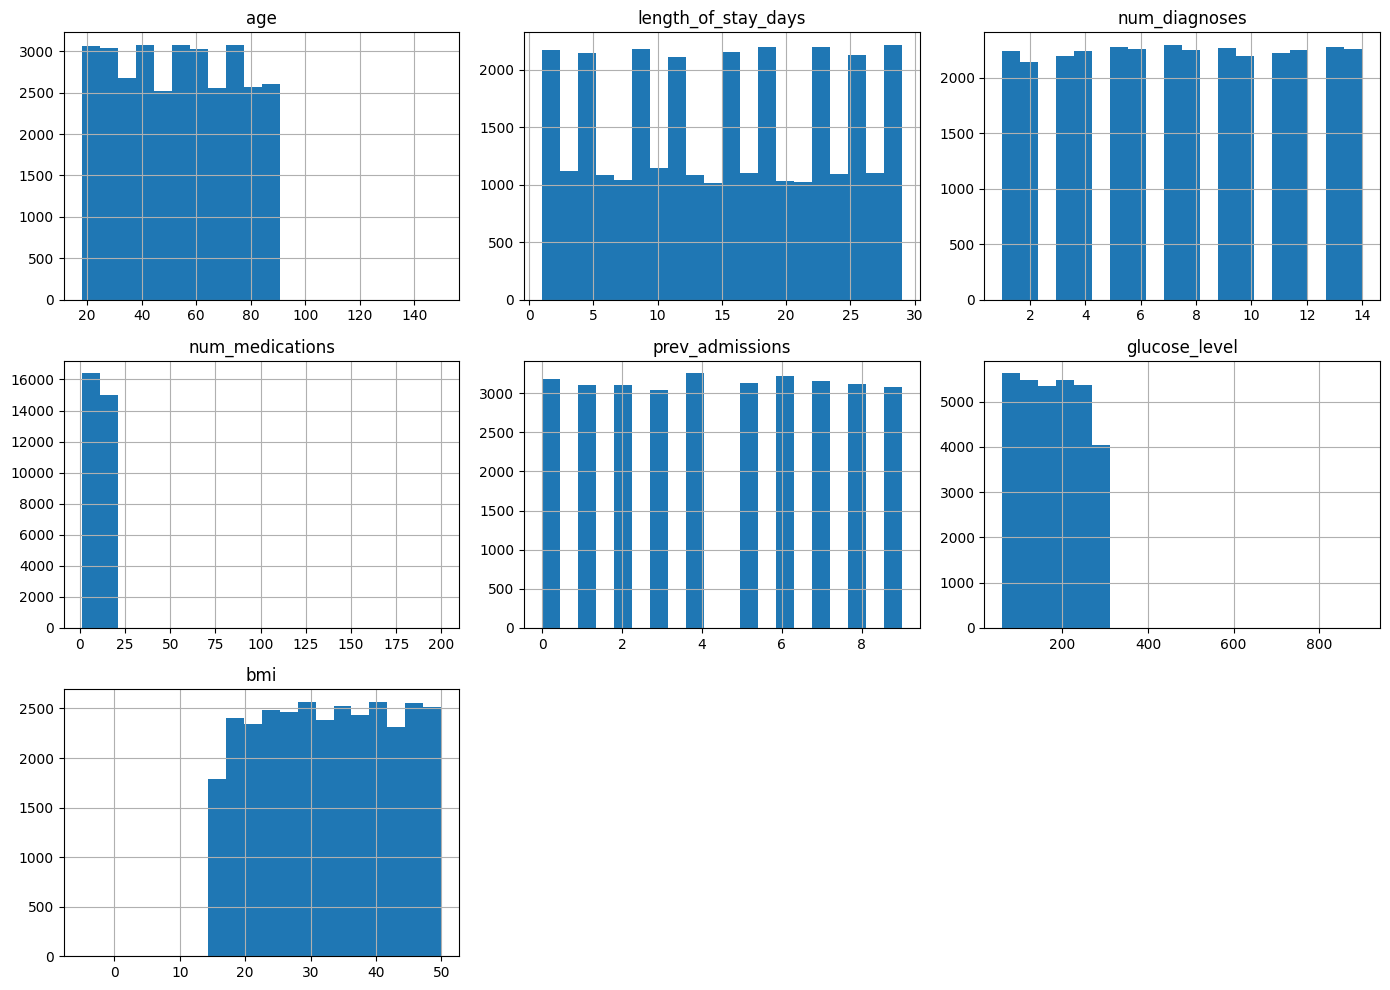

In [ ]:
numeric_columns = [
    "age",
    "length_of_stay_days",
    "num_diagnoses",
    "num_medications",
    "prev_admissions",
    "glucose_level",
    "bmi"
]

df[numeric_columns].hist(
    figsize=(14, 10),
    bins=20
)

plt.tight_layout()
plt.show()

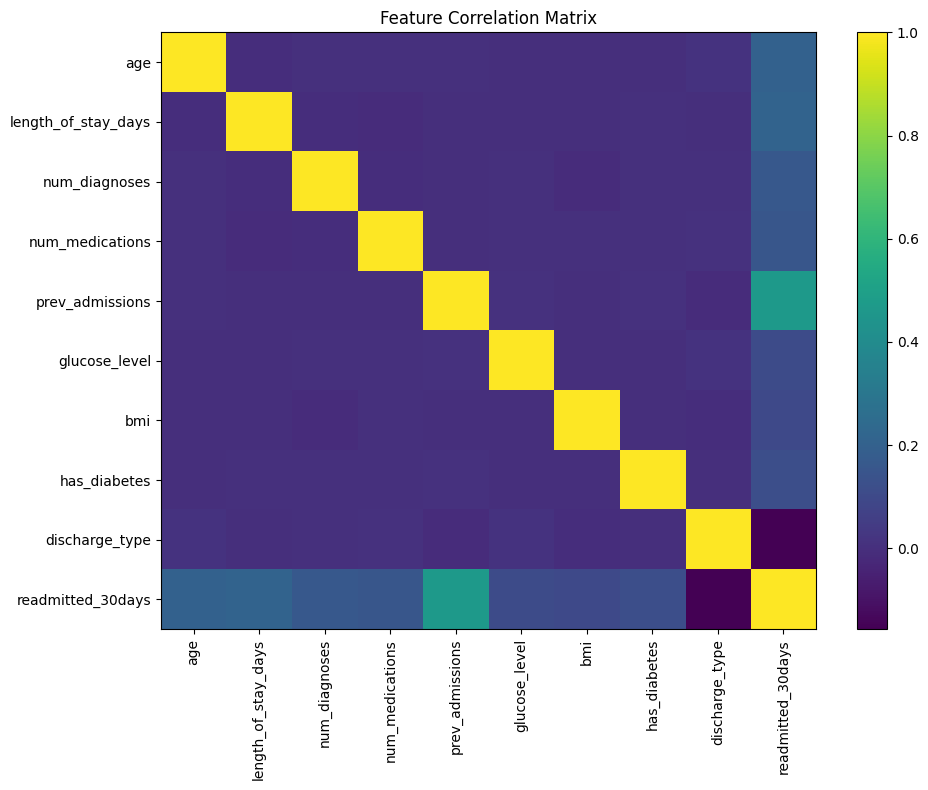

In [ ]:
correlation = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))

plt.imshow(correlation, aspect="auto")

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.colorbar()

plt.title("Feature Correlation Matrix")

plt.tight_layout()
plt.show()

In [ ]:
y = df["readmitted_30days"]

In [ ]:
X = df.drop(columns=["readmitted_30days"])

In [ ]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (32002, 9)
y shape: (32002,)


In [ ]:
X = X.copy()

for column in X.columns:
    X[column] = pd.to_numeric(X[column], errors="coerce")

X = X.fillna(X.median())

In [ ]:
print("Missing values remaining:", X.isnull().sum().sum())

Missing values remaining: 0


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (25601, 9)
Testing data: (6401, 9)


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [ ]:
model = LogisticRegression(
    penalty="l2",
    C=1.0,
    max_iter=1000,
    random_state=42
)

In [ ]:
model.fit(X_train_scaled, y_train)

print("Model training completed!")

Model training completed!


In [ ]:
y_pred = model.predict(X_test_scaled)

In [ ]:
y_prob = model.predict_proba(X_test_scaled)[:, 1]

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7915950632713639


In [ ]:
roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.8752215620539715


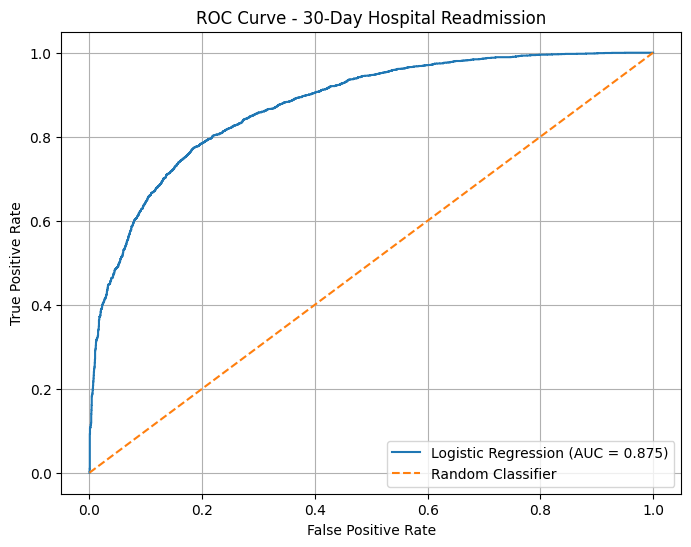

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - 30-Day Hospital Readmission")
plt.legend()
plt.grid()
plt.show()

In [ ]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[2549  656]
 [ 678 2518]]


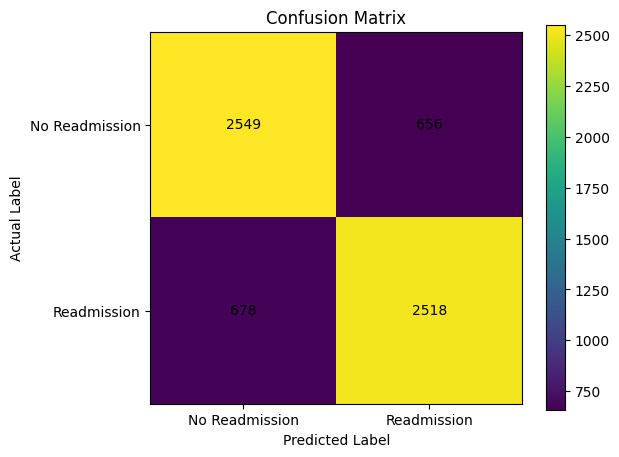

In [ ]:
plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Confusion Matrix")

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks(
    [0, 1],
    ["No Readmission", "Readmission"]
)

plt.yticks(
    [0, 1],
    ["No Readmission", "Readmission"]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.show()

In [ ]:
tn, fp, fn, tp = cm.ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

True Negatives : 2549
False Positives: 656
False Negatives: 678
True Positives : 2518


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.79      0.80      0.79      3205
           1       0.79      0.79      0.79      3196

    accuracy                           0.79      6401
   macro avg       0.79      0.79      0.79      6401
weighted avg       0.79      0.79      0.79      6401



## Clinical Cost of False Positives and False Negatives

A false negative occurs when the model predicts that a patient will not be readmitted within 30 days, but the patient is actually readmitted.

In a clinical setting, false negatives can be particularly concerning because a high-risk patient may not receive additional follow-up, monitoring, discharge planning, medication review, or other preventive interventions. Therefore, a false negative may represent a missed opportunity for early intervention.

A false positive occurs when the model predicts that a patient will be readmitted within 30 days, but the patient is not actually readmitted.

False positives can result in additional healthcare resources being used for patients who may not require them. Examples include additional monitoring, follow-up appointments, care-management services, and other preventive interventions.

For this application, false negatives may therefore have a higher clinical cost than false positives. However, reducing false negatives can increase the number of false positives. The appropriate prediction threshold should ultimately depend on the hospital's available resources and the relative clinical costs of the two types of errors.

Consequently, ROC-AUC is useful for evaluating the model's overall ability to distinguish between the two classes, while the final classification threshold should be selected according to the clinical objective.


In [ ]:
fn_cost = 5
fp_cost = 1

total_error_cost = (fn * fn_cost) + (fp * fp_cost)

print("Illustrative False Negative Cost:", fn * fn_cost)
print("Illustrative False Positive Cost:", fp * fp_cost)
print("Total Illustrative Error Cost:", total_error_cost)

Illustrative False Negative Cost: 3390
Illustrative False Positive Cost: 656
Total Illustrative Error Cost: 4046


In [ ]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coefficients["Absolute_Coefficient"] = (
    coefficients["Coefficient"].abs()
)

coefficients = coefficients.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

coefficients

,Feature,Coefficient,Absolute_Coefficient
4,prev_admissions,1.470535,1.470535
1,length_of_stay_days,0.737130,0.737130
0,age,0.689193,0.689193
3,num_medications,0.557909,0.557909
2,num_diagnoses,0.550879,0.550879
8,discharge_type,-0.538961,0.538961
7,has_diabetes,0.403163,0.403163
6,bmi,0.343424,0.343424
5,glucose_level,0.331991,0.331991


## Conclusion

In this project, Logistic Regression with L2 regularization was used to predict whether a patient would be readmitted within 30 days.

The patient and hospital-related features were cleaned, converted into numerical form, scaled, and divided into training and testing sets. The model was then trained using L2-regularized Logistic Regression.

The model was evaluated using ROC-AUC, confusion matrix, accuracy, precision, recall, and F1-score. ROC-AUC was selected as the primary evaluation metric because it evaluates the model's ability to distinguish between patients with and without 30-day readmission across different classification thresholds.

The analysis of false positives and false negatives shows that prediction errors can have different clinical consequences. In particular, false negatives may be more concerning because they can cause high-risk patients to be overlooked for additional intervention.

Overall, the project demonstrates how machine learning can be applied to hospital readmission risk prediction while also highlighting the importance of considering clinical consequences when selecting a classification threshold.
